# Simple Kernel SHAP

This notebook provides a simple brute force version of Kernel SHAP that enumerates the entire $2^M$ sample space. We also compare this implementation against the `shap.KernelExplainer`. Note that `shap.KernelExplainer` does a sampling approximation for large values of $M$, but for small values it is exact.

### Brute Force Kernel SHAP

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import scipy.special

import shap

In [2]:
def powerset(iterable):
    s = list(iterable)
    return itertools.chain.from_iterable(itertools.combinations(s, r) for r in range(len(s) + 1))


def shapley_kernel(M, s):
    """
    Computes the SHAP kernel weight.
    Formula: k(M, s) = (M - 1) / (binom(M, s) * s * (M - s))
    High weights are given to small and large subsets to enforce consistency.
    """
    if s == 0 or s == M:
        return 10000
    return (M - 1) / (scipy.special.binom(M, s) * s * (M - s))


def f(X):
    """A simple linear model with a bias term (10)."""
    np.random.seed(0)
    beta = np.random.rand(X.shape[-1])
    return np.dot(X, beta) + 10


def kernel_shap(f, x, reference, M):
    """
    Calculates SHAP values by solving a Weighted Least Squares (WLS) problem.
    """
    X = np.zeros((2**M, M + 1))
    X[:, -1] = 1
    weights = np.zeros(2**M)
    V = np.zeros((2**M, M))
    for i in range(2**M):
        V[i, :] = reference

    ws = {}
    for i, s in enumerate(powerset(range(M))):
        s = list(s)
        V[i, s] = x[s]
        X[i, s] = 1
        ws[len(s)] = ws.get(len(s), 0) + shapley_kernel(M, len(s))
        weights[i] = shapley_kernel(M, len(s))
    y = f(V)

    # Apply WLS: W^(1/2) * X * result = W^(1/2) * y
    wsq = np.sqrt(weights)
    result = np.linalg.lstsq(wsq[:, None] * X, wsq * y, rcond=None)[0]
    return result


M = 4
np.random.seed(1)
x = np.random.randn(M)
reference = np.zeros(M)
feature_names = [f"Feature {i}" for i in range(M)]

phi = kernel_shap(f, x, reference, M)
manual_base_value = phi[-1]
manual_shap_values = phi[:-1]

print("         reference =", reference)
print("                 x =", x)
print("manual_shap_values =", manual_shap_values)
print(" manual_base_value =", manual_base_value)
print("          sum(phi) =", np.sum(phi))
print("              f(x) =", f(x))

         reference = [0. 0. 0. 0.]
                 x = [ 1.62434536 -0.61175641 -0.52817175 -1.07296862]
manual_shap_values = [ 0.89146267 -0.43752168 -0.31836259 -0.58464256]
 manual_base_value = 10.000000000000007
          sum(phi) = 9.550935842131224
              f(x) = 9.55093584213122


### Using KernelExplainer

In [3]:
explainer = shap.KernelExplainer(f, np.reshape(reference, (1, len(reference))))
library_shap_values = explainer.shap_values(x)
print("library shap values =", library_shap_values)
print(" library base value =", explainer.expected_value)

library shap values = [ 0.89146267 -0.43752168 -0.31836259 -0.58464256]
 library base value = 10.0


### Visualization and Analysis

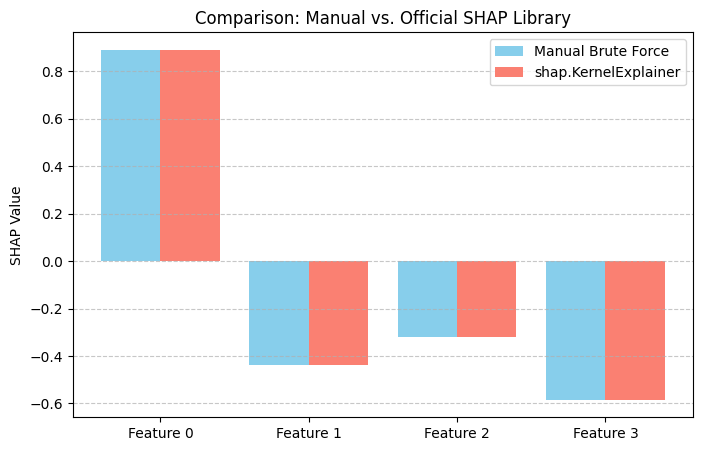

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(np.arange(M) - 0.2, manual_shap_values, 0.4, label="Manual Brute Force", color="skyblue")
plt.bar(np.arange(M) + 0.2, library_shap_values, 0.4, label="shap.KernelExplainer", color="salmon")
plt.xticks(np.arange(M), feature_names)
plt.ylabel("SHAP Value")
plt.title("Comparison: Manual vs. Official SHAP Library")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

We can see that, the results from both the approaches are same.

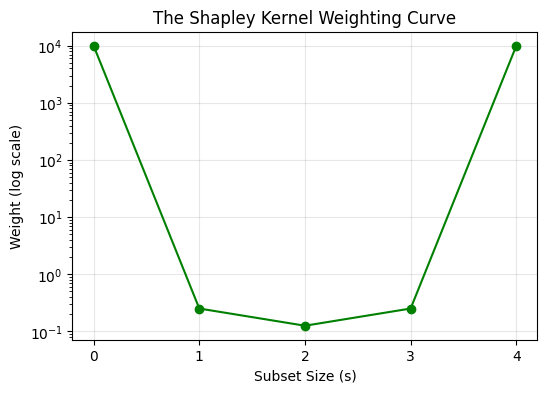

In [5]:
# WEIGHTING TABLE: Visualizing how the Kernel weights subsets
subset_sizes = np.arange(M + 1)
weights_per_size = [shapley_kernel(M, s) for s in subset_sizes]

plt.figure(figsize=(6, 4))
plt.plot(subset_sizes, weights_per_size, marker="o", linestyle="-", color="green")
plt.yscale("log")
plt.title("The Shapley Kernel Weighting Curve")
plt.xlabel("Subset Size (s)")
plt.ylabel("Weight (log scale)")
plt.xticks(subset_sizes)
plt.grid(True, alpha=0.3)
plt.show()